This script plots various aspects of the TrappedResonance objective function

In [1]:
import desc.io
from desc.objectives import (
    TrappedResonance
)
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [2]:
# User Inputs #
eq = desc.io.load("equil_Helios_E0090-13_DESC_fixed.h5")

rhos = (np.linspace(0.1,0.9,15))**(1/2) # rho = sqrt(s)
alphas = np.linspace(0,2*np.pi,1)
KE_frac = np.array([0.01])
pitch_invs = jnp.array([5.0,5.1,5.2])

In [3]:
# Run objective function
obj = TrappedResonance(eq,rho=rhos,pitch_invs=pitch_invs,KE_frac=KE_frac,alpha=alphas,N=0)
obj.build()
obj_out = obj.compute(eq.params_dict) # when not flattened, this shape is (rho,pitch,energy)

Precomputing transforms


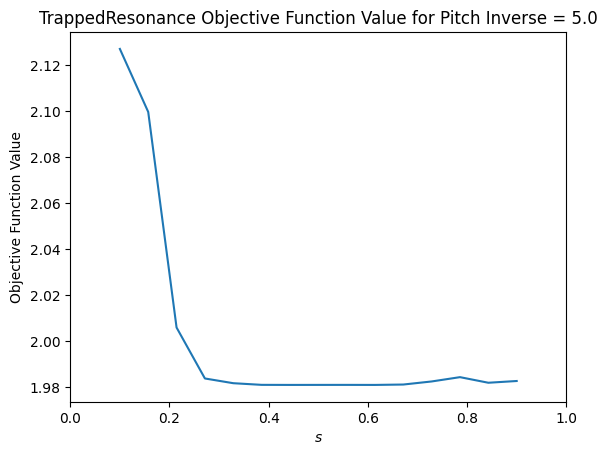

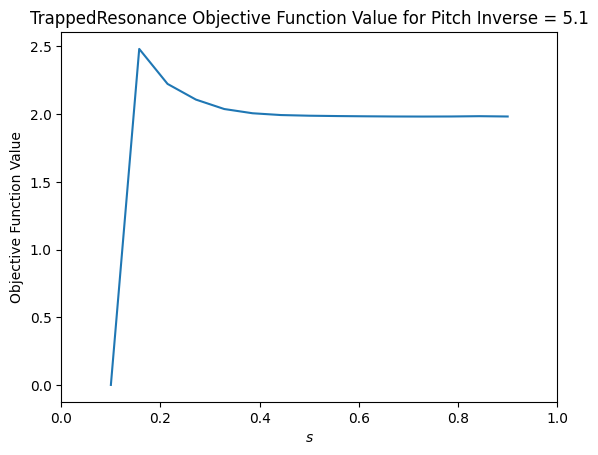

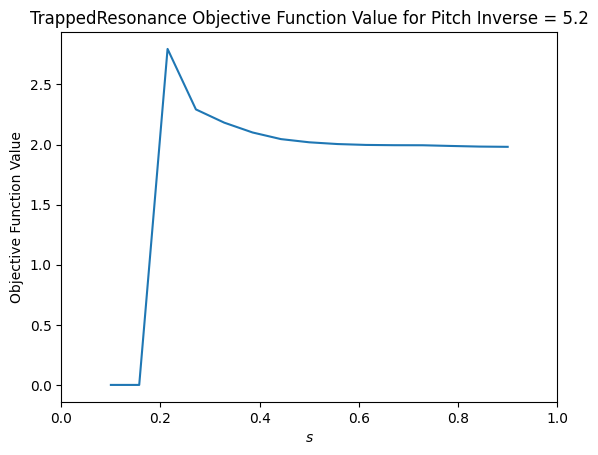

In [4]:
# Plot s vs. obj_out for each pitch inverse
for i in range(0,obj_out.shape[1]): # loop through each pitch angle
    plt.figure(i+1)
    plt.plot(rhos**2,obj_out[:,i,0]) # assuming we are only doing 1 energy for now
    plt.xlabel(r'$s$')
    plt.ylabel('Objective Function Value')
    plt.title('TrappedResonance Objective Function Value for Pitch Inverse = '+str(pitch_invs[i]))
    # plt.ylabel(r'$\omega_{\zeta}$')
    # plt.title(r'$\omega_{\zeta}$ Value for Pitch Inverse = '+str(pitch_invs[i]))
    plt.xlim([0.0,1.0])

In [6]:
print(obj_out[:,0,0])

[            nan             nan             nan             nan
  1.67328351e-03  3.44955099e-04 -5.44600192e-05 -2.14677885e-04
 -2.67228605e-04 -2.32958897e-05  8.11231950e-04  2.37931698e-03
  3.49400684e-03  1.79228704e-03 -2.32859175e-03]
